In [2]:
import cv2
import numpy as np

SZ=20
bin_n = 16 # bins 數 目
affine_flags = cv2.WARP_INVERSE_MAP|cv2.INTER_LINEAR

def deskew(img):
    m = cv2.moments(img)
    if abs(m['mu02']) < 1e-2:
        return img.copy()
    skew = m['mu11']/m['mu02']
    M = np.float32([[1, skew, -0.5*SZ*skew], [0, 1, 0]])
    img = cv2.warpAffine(img,M,(SZ, SZ),flags=affine_flags)
    return img

def hog(img):
    hog = cv2.HOGDescriptor(
        _winSize=(20, 20),
        _blockSize=(10, 10),
        _blockStride=(10, 10),
        _cellSize=(10, 10),
        _nbins=16
    )
    h = hog.compute(img)
    return h.flatten()

#每個單元格的 HOG descriptor在 X 和 Y 方向 找到每個單元的 Sobel導數
#然後在每個像素處找到它們的大小和梯度方向該梯度量化為16個整數值
#將此圖像分為 四個子方塊對於每個子平方，計算方向的直方圖（16個區間）加權其大小,因此每個子方格都會為您提供一個包含16個值的向量
#四個這樣的向量（四個子方塊一起給出了包含64個值的特徵向量

img = cv2.imread('data/digits.png',0)
# img = cv2.imread('data/digits.png',0)


if img is None:
    raise Exception("we need the digits.png image from samples/data here !")
cells = [np.hsplit(row,100) for row in np.vsplit(img,50)]


# 50% -trainData， 50% -testData 

train_cells = [ i[:50] for i in cells ]
test_cells = [ i[50:] for i in cells]
deskewed = [list(map(deskew,row)) for row in train_cells]
hogdata = [list(map(hog,row)) for row in deskewed]
trainData = np.float32(hogdata).reshape(-1,64)
responses = np.repeat(np.arange(10),250)[:,np.newaxis]
svm = cv2.ml.SVM_create()
svm.setKernel(cv2.ml.SVM_LINEAR)
svm.setType(cv2.ml.SVM_C_SVC)
svm.setC(2.67)
svm.setGamma(5.383)
svm.train(trainData, cv2.ml.ROW_SAMPLE, responses)
svm.save('svm_data.dat')

deskewed = [list(map(deskew,row)) for row in test_cells]
hogdata = [list(map(hog,row)) for row in deskewed]
testData = np.float32(hogdata).reshape(-1,64)
result = svm.predict(testData)[1]
mask = result==responses

correct = np.count_nonzero(mask)
print(correct*100.0/result.size)

93.56


In [4]:
import cv2
import numpy as np

face_classifier = cv2.CascadeClassifier('Haarcascades/haarcascade_frontalface_default.xml')
eye_classifier = cv2.CascadeClassifier('Haarcascades/haarcascade_eye_tree_eyeglasses.xml')
#https://github.com/opencv/opencv/tree/master/data/haarcascades

def face_detector(img, size=0.5):
    
# 圖像 轉換 Convert  為 灰色 - GrayScale
    
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    faces = face_classifier.detectMultiScale(gray, 1.3, 5)
    if faces is ():
        return img
    
    for (x,y,w,h) in faces:
        x = x - 50
        w = w + 50
        y = y - 50
        h = h + 50
        cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_classifier.detectMultiScale(roi_gray)
        
        for (ex,ey,ew,eh) in eyes:
            cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,0,255),2) 
            
    #roi_color = cv2.flip(roi_color,1)
    return img


cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()
    cv2.imshow('Our Face Extractor', face_detector(frame))
    if cv2.waitKey(20) == 13:        # 13 is the Enter Key
        break
        
cap.release()
cv2.destroyAllWindows()
for i in range (1,5):
    cv2.waitKey(1)

<>:14: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:14: SyntaxWarning: "is" with a literal. Did you mean "=="?
/var/folders/22/50jgjg5n7hq_d7rvk2d3l0xc0000gp/T/ipykernel_95450/581482878.py:14: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if faces is ():


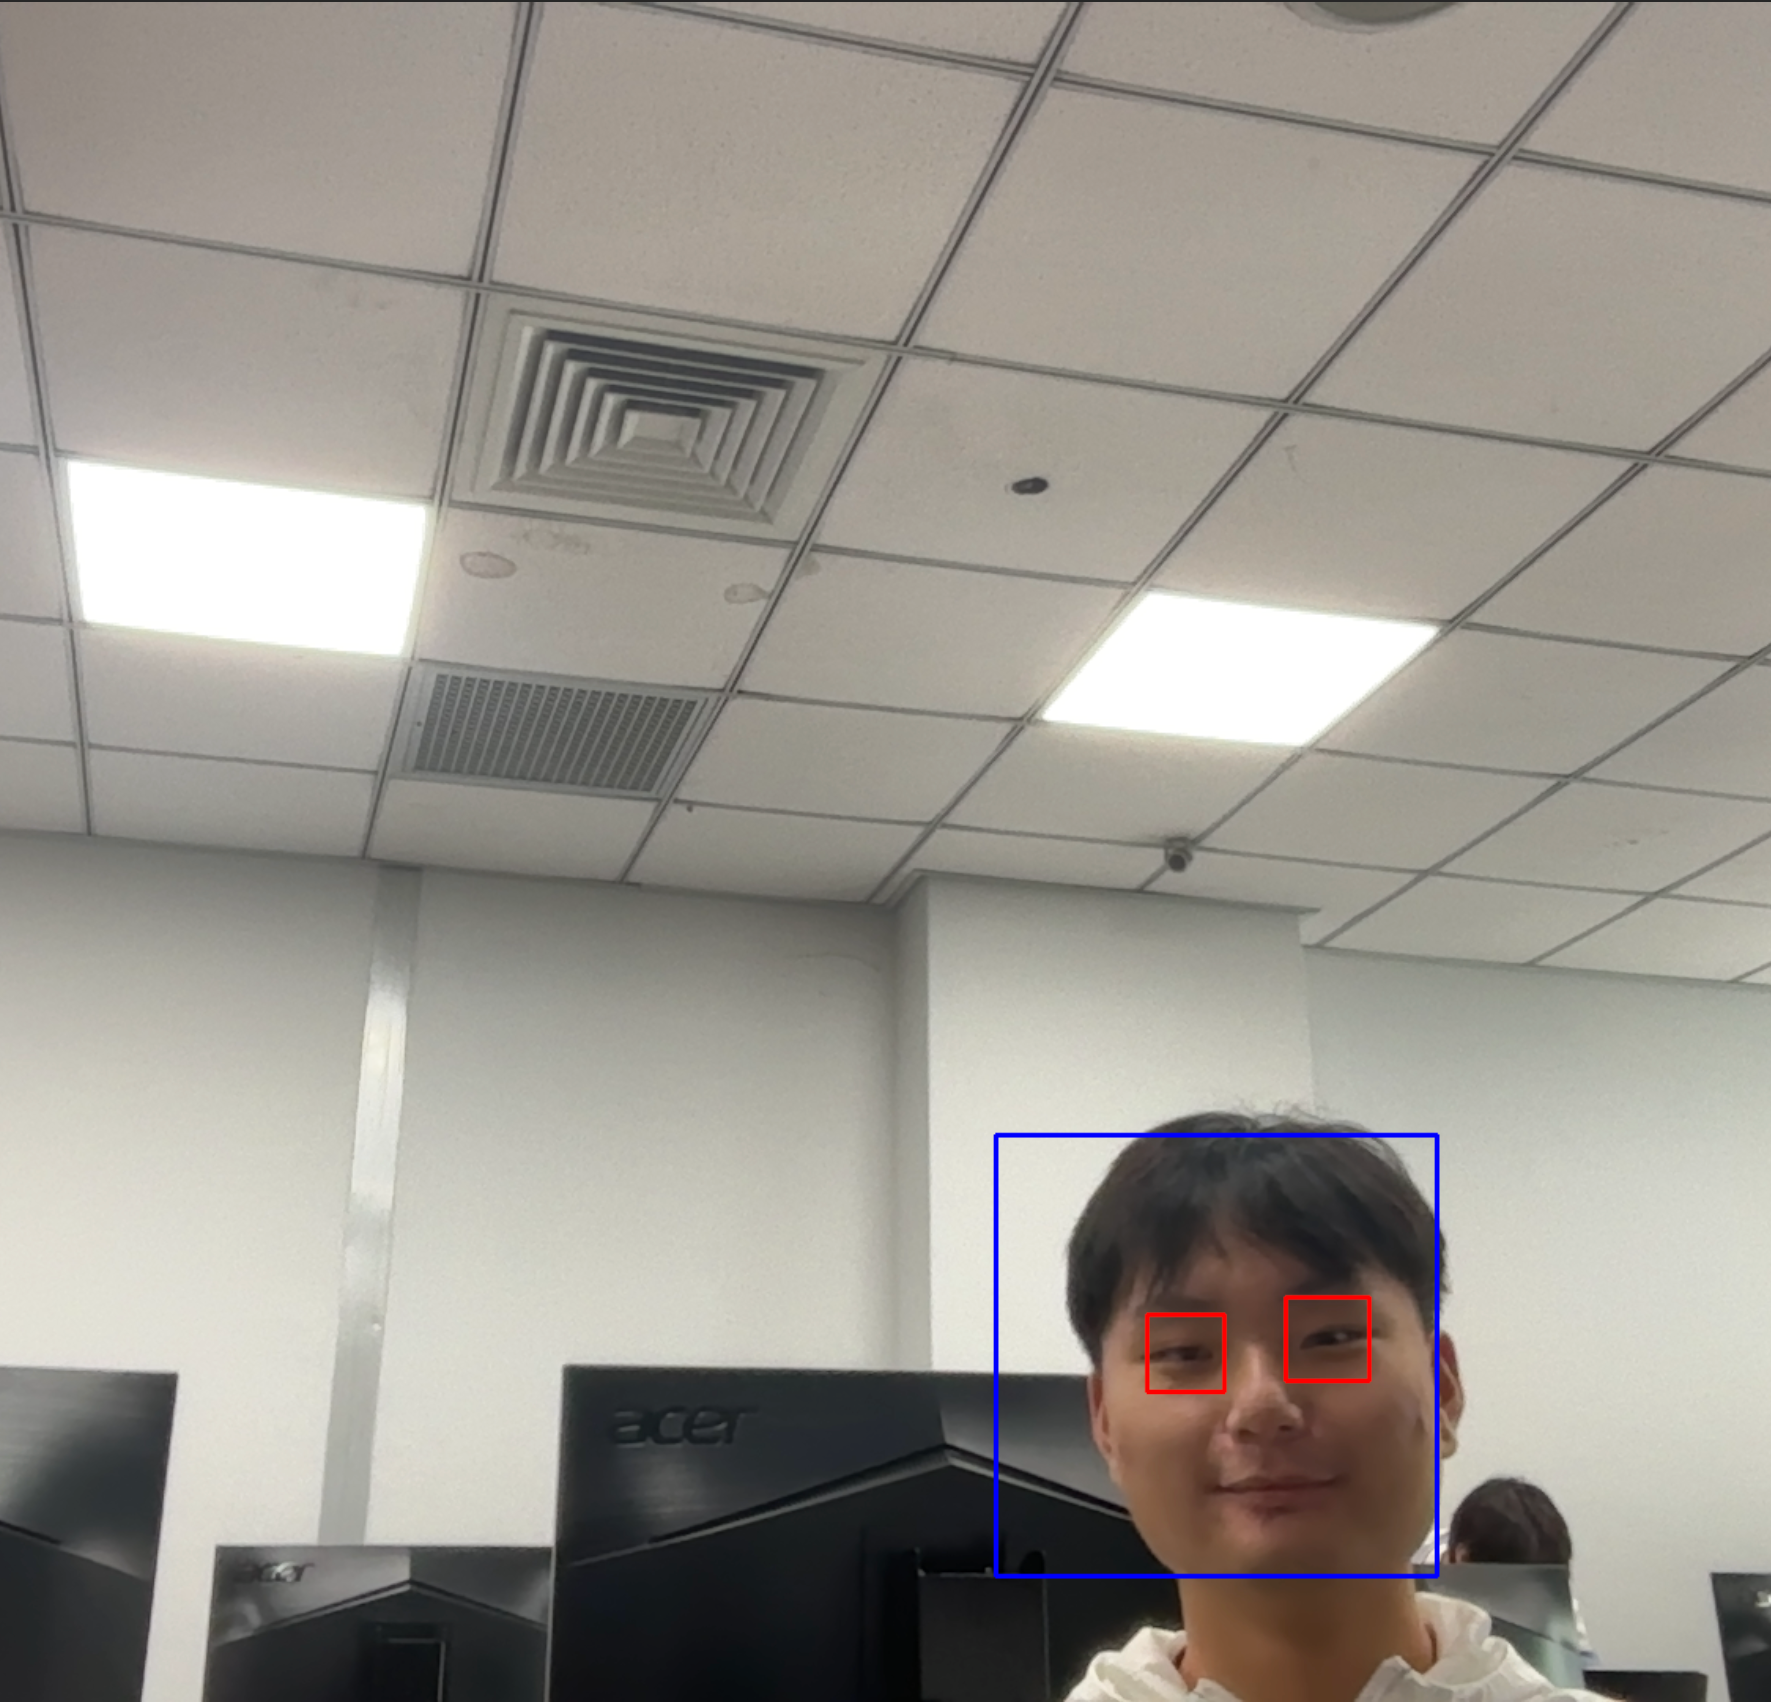